# Análisis Exploratorio del Rendimiento Académico de Estudiantes Universitarios de Programas de Pregrado Presencial 

Estudiantes:

MARIA JOSÉ BERRIO CHASOY, Magister en Ciencias de la Tierra. 
CÉSAR GUILLERMO ANACHURY PACHECO, Magister en Estadística Aplicada.
JOSÉ JAVIER CASTRO CERVANTES, Magister en Economía.

Introducción

La deserción estudiantil y el bajo rendimiento académico constituyen problemáticas centrales en las instituciones de educación superior, debido a sus efectos sobre la calidad educativa, la reputación institucional y la sostenibilidad del sistema (Gallego et al., 2021). En Colombia, las tasas de deserción universitaria superan el promedio de los países de la OCDE, reflejando debilidades estructurales relacionadas con factores económicos, sociales, institucionales y pedagógicos (Ministerio de Educación Nacional – SPADIES, 2025). Entre las causas más relevantes de deserción se encuentra el bajo rendimiento académico, indicador que refleja la capacidad del estudiante para alcanzar los objetivos de aprendizaje y adaptarse a las exigencias del entorno educativo (Imig, 2020)

Tradicionalmente, el rendimiento académico se ha evaluado mediante indicadores descriptivos como el promedio general acumulado (GPA). Sin embargo, la creciente disponibilidad de datos educativos y los avances en la ciencia de datos han impulsado la emergencia de la Minería de Datos Educativos (MDE). Este campo utiliza modelos predictivos avanzados para comprender y anticipar fenómenos clave como el rendimiento, la retención, la satisfacción y la deserción (Alyahyan & Düştegör, 2020). En Colombia, esta necesidad se articula con iniciativas como el Sistema de Prevención y Análisis de la Deserción en Instituciones de Educación Superior (SPADIES), que facilita el monitoreo y el diseño de acciones diferenciadas (Pérez et al., 2018). Estas herramientas se enmarcan en la metodología KDD (Knowledge Discovery in Databases), que integra la recolección, transformación y análisis de datos para generar conocimiento útil en la toma de decisiones educativas (Rico Páez & Sánchez Guzmán, 2018). 

Algoritmos como XGBoost (Extreme Gradient Boosting) se destacan en esta área, demostrando ser altamente eficaces para manejar grandes volúmenes de datos, capturar relaciones no lineales y realizar predicciones precisas en tareas de clasificación y regresión, lo que resulta fundamental para evaluar la importancia relativa de las variables académicas en el desempeño estudiantil.

El presente proyecto tiene como objetivo analizar, modelar y predecir el rendimiento académico de los estudiantes —considerado un indicador indirecto de deserción— a partir de variables académicas y de desempeño, mediante técnicas estadísticas descriptivas, inferenciales y de aprendizaje automático. Con datos públicos de una universidad colombiana (2014–2023), que incluyen calificaciones y variables de contexto académico, se busca identificar los factores más influyentes sobre la nota final y estimar la probabilidad de bajo rendimiento. Los resultados aspiran a fortalecer la detección temprana de estudiantes en riesgo y apoyar la toma de decisiones institucionales orientadas a mejorar la calidad y la permanencia en la educación superior.


Objetivos

General

Analizar, modelar y predecir el rendimiento académico de los estudiantes a partir de variables socioacadémicas y de desempeño, mediante técnicas estadísticas descriptivas, inferenciales y de aprendizaje automático basadas en el algoritmo XGBoost, con el propósito de identificar patrones, relaciones significativas y factores determinantes que inciden en la nota final y en los niveles de rendimiento académico.

Específicos

Identificar la estructura y características del conjunto de datos, resaltando sus dimensiones, tipos de varibles (𝑋𝑖: cuantitativas y cualitativas) y variable de interés (𝑌: dependiente).

Realizar un análisis exploratorio en función de la variable dependiente (𝑌), caracterizando su distribución y evaluando patrones, tendencias y posibles sesgos en los datos.

Llevar a cabo un análisis estadístico de las variables numéricas con el fin de: verificar la normalidad de las distribuciones (Ho : Xi ∼ N(μ,σ2)), estimar correlaciones significativas entre variables cuantitativas (rPearson) y analizar asociaciones entre variables categóricas mediante pruebas de independencia (𝜒2)

Desarrollar y evaluar un modelo de clasificación ordinal utilizando el algoritmo XGBoost, con el propósito de predecir la variable “Rendimiento” e identificar las variables predictoras con mayor peso estadístico en la explicación del desempeño académico de los estudiantes.

Exploración de los Datos (-EDA-)

1. Transformación de los Datos

Antes de realizar un Análisis Exploratorio de los Datos, es necesario transformar la información de distintas formas. Para ello, se ha hecho uso de diferentes paquetes y librerias que ofrecen un conjunto de funciones que facilitan el manejo de estos de manera estructurada y eficiente.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.ticker as mtick
from matplotlib.ticker import MultipleLocator
from tabulate import tabulate
import IPython.display as disp
from scipy.stats import chi2_contingency, kstest
from scipy.stats import norm as normal_dist
from IPython.display import display, HTML
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import pairwise_distances
from sklearn.metrics import silhouette_score
import random
from sklearn.decomposition import PCA
from matplotlib.patches import Ellipse
from scipy.spatial.distance import cityblock
import plotly.express as px
import warnings

In [2]:
import pandas, matplotlib, seaborn, numpy, scipy, sklearn, plotly
print("✅ Todas las librerías están instaladas correctamente.")

✅ Todas las librerías están instaladas correctamente.


In [3]:
# Leer el archivo Excel
df = pd.read_excel('SAR.xlsx', engine="openpyxl")

KeyboardInterrupt: 

In [58]:
# Obtener las dimensiones del DataFrame
df.shape

(590415, 16)

In [59]:
# Número total de elementos en el dataframe
df.size

9446640

In [60]:
# Obtener información sobre la estructura del DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590415 entries, 0 to 590414
Data columns (total 16 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Facultad            590415 non-null  object 
 1   Programa            590415 non-null  object 
 2   Código Estudiantil  590415 non-null  int64  
 3   Código Asignatura   590415 non-null  object 
 4   Asignatura          590415 non-null  object 
 5   Grupo               590415 non-null  object 
 6   Nota 1              590415 non-null  float64
 7   Nota 2              590415 non-null  float64
 8   Nota 3              590415 non-null  float64
 9   Nota 4              590415 non-null  float64
 10  Nota Definitiva     590415 non-null  float64
 11  Nota Habilitación   590415 non-null  float64
 12  Nota Final          590415 non-null  float64
 13  Rendimiento         590415 non-null  object 
 14  Año                 590415 non-null  int64  
 15  Periodo             590415 non-nul

De lo anterior se resalta que la base de datos cuenta con 590415 observaciones de 16 variables relacionadas con el Rendimiento Académico.

In [61]:
# Eliminar filas duplicadas
df = df.drop_duplicates()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 590412 entries, 0 to 590414
Data columns (total 16 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Facultad            590412 non-null  object 
 1   Programa            590412 non-null  object 
 2   Código Estudiantil  590412 non-null  int64  
 3   Código Asignatura   590412 non-null  object 
 4   Asignatura          590412 non-null  object 
 5   Grupo               590412 non-null  object 
 6   Nota 1              590412 non-null  float64
 7   Nota 2              590412 non-null  float64
 8   Nota 3              590412 non-null  float64
 9   Nota 4              590412 non-null  float64
 10  Nota Definitiva     590412 non-null  float64
 11  Nota Habilitación   590412 non-null  float64
 12  Nota Final          590412 non-null  float64
 13  Rendimiento         590412 non-null  object 
 14  Año                 590412 non-null  int64  
 15  Periodo             590412 non-null  in

In [62]:
# Conteo de valores faltantes por columna
print("Valores faltantes por columna:")
print(df.isnull().sum())

# 4. Filas con al menos un valor faltante
print("\nNúmero de filas con datos faltantes:", df.isnull().any(axis=1).sum())

# 2. Total de valores faltantes en todo el dataset
print("\nTotal de valores faltantes en el DataFrame:", df.isnull().sum().sum())

Valores faltantes por columna:
Facultad              0
Programa              0
Código Estudiantil    0
Código Asignatura     0
Asignatura            0
Grupo                 0
Nota 1                0
Nota 2                0
Nota 3                0
Nota 4                0
Nota Definitiva       0
Nota Habilitación     0
Nota Final            0
Rendimiento           0
Año                   0
Periodo               0
dtype: int64

Número de filas con datos faltantes: 0

Total de valores faltantes en el DataFrame: 0


In [63]:
# Conteo de valores nulos por columna
print("\nCantidad de nulos por columna:")
print(df.isnull().sum())

# Número de filas con al menos un nulo
print("\nNúmero de filas con al menos un valor nulo:", df.isnull().any(axis=1).sum())

# Total de nulos en el dataset
print("\nTotal de valores nulos en el dataset:", df.isnull().sum().sum())

# Verificar si hay nulos en el DataFrame (True/False)
print("¿Hay valores nulos en el dataset?:", df.isnull().values.any())


Cantidad de nulos por columna:
Facultad              0
Programa              0
Código Estudiantil    0
Código Asignatura     0
Asignatura            0
Grupo                 0
Nota 1                0
Nota 2                0
Nota 3                0
Nota 4                0
Nota Definitiva       0
Nota Habilitación     0
Nota Final            0
Rendimiento           0
Año                   0
Periodo               0
dtype: int64

Número de filas con al menos un valor nulo: 0

Total de valores nulos en el dataset: 0
¿Hay valores nulos en el dataset?: False


Después de eliminar las filas duplicadas y verificar la no existensia de datos faltantes en el dataset, el análisis posterior se ha facilitado, ya que no es necesario aplicar técnicas de imputación. A continuación, se presenta la descripción de las variables que conforman el conjunto de datos, en la cual se distinguen atributos categóricos —tanto nominales como ordinales-, así como variables numéricas -tanto continuas como discretas-.

2. Estructura y Características de la Base de Datos: Student Academic Record.

La siguiente tabla, detalla la Estructura y Características de la base de datos "Student Academic Record". Su configuración incluye cinco columnas: "Clase de Atributo", que agrupa las variables según su naturaleza; "Atributo", que indica el nombre de cada variable registrada en la base; "Tipo", que define la naturaleza de los datos como "categóricos" o "numéricos", y dentro de ellos, "nominales", "ordinales", "continuos" o "discretos"; "Count", que presenta el número total de registros (observaciones), en este caso 590.412 para todas las variables; y Missing (value), que señala la ausencia de valores faltantes, siendo 0 en todos los casos (tanto para las filas como para las columnas).

In [64]:
var_types = [
    ("Información Académica", "Facultad", "Categórica / Nominal", "590412", "0"),
    ("Información Académica", "Programa Académico", "Categórica / Nominal", "590412", "0"),
    ("Información Académica", "Código Asignatura", "Categórica / Nominal", "590412", "0"),
    ("Información Académica", "Asignatura / Materia", "Categórica / Nominal", "590412", "0"),
    ("Información Académica", "Grupo", "Categórica / Nominal", "590412", "0"),
    ("Información Académica", "Código Estudiantil", "Numérica / Continua",  "590412", "0"),
    ("Record de Notas", "Nota 1", "Numérica / Continua", "590412", "0"),
    ("Record de Notas", "Nota 2", "Numérica / Continua", "590412", "0"),
    ("Record de Notas", "Nota 3", "Numérica / Continua", "590412", "0"),
    ("Record de Notas", "Nota 4", "Numérica / Continua", "590412", "0"),
    ("Record de Notas", "Nota Definitiva", "Numérica / Continua", "590412", "0"),
    ("Record de Notas", "Nota Habilitación", "Numérica / Continua", "590412", "0"),
    ("Record de Notas", "Nota Final", "Numérica / Continua", "590412", "0"),
    ("Desempeño Estudiantil", "Rendimiento", "Categórica / Ordinal", "590412", "0"),
    ("Datos Temporales", "Año", "Numérica / Discreta", "590412", "0"),
    ("Datos Temporales", "Periodo", "Numérica / Discreta", "590412", "0")
]

# Crear DataFrame
tabla_vars = pd.DataFrame(
    var_types,
    columns=["Clase de Atributo", "Atributo", "Tipo", "Count", "Missing"]
)

# Mostrar con estilo
tabla_vars = (
    tabla_vars.style
              .set_table_attributes('style="width:100%; margin-left:auto; margin-right:auto;"')
              .set_properties(**{'text-align': 'left'})
              .set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]}])
              .hide(axis="index")
)

tabla_vars

Clase de Atributo,Atributo,Tipo,Count,Missing
Información Académica,Facultad,Categórica / Nominal,590412,0
Información Académica,Programa Académico,Categórica / Nominal,590412,0
Información Académica,Código Asignatura,Categórica / Nominal,590412,0
Información Académica,Asignatura / Materia,Categórica / Nominal,590412,0
Información Académica,Grupo,Categórica / Nominal,590412,0
Información Académica,Código Estudiantil,Numérica / Continua,590412,0
Record de Notas,Nota 1,Numérica / Continua,590412,0
Record de Notas,Nota 2,Numérica / Continua,590412,0
Record de Notas,Nota 3,Numérica / Continua,590412,0
Record de Notas,Nota 4,Numérica / Continua,590412,0


En este sentido, dentro de la clase Información Académica, se encuentran variables que describen el contexto académico del estudiante. Estas son: Facultad, Programa Académico, Código Asignatura, Asignatura/Materia, Grupo y Código Estudiantil. Las cinco primeras son de tipo categórico nominal, mientras que el Código Estudiantil está clasificado como numérico continuo.

La clase Record de Notas agrupa las variables relacionadas con las calificaciones de los estudiantes. Incluye las notas parciales (Nota 1, Nota 2, Nota 3 y Nota 4), la Nota Definitiva, la Nota de Habilitación y la Nota Final. Todas estas variables están definidas como numéricas continuas.

En la clase Desempeño Estudiantil aparece el atributo Rendimiento, el cual se encuentra definido como categórico ordinal con cinco niveles, estos son: Deficiente, Bajo, Medio, Alto y Superior.

Finalmente, en la clase Datos Temporales se encuentran los atributos Año y Periodo. Ambos son de tipo numérico discreto.

En resumen, la tabla organiza de manera estructurada la información de la base de datos, mostrando que todas las variables contienen 590.412 registros completos, sin valores faltantes, y clasificando cada atributo de acuerdo con su tipo de dato y naturaleza.

In [65]:
# Imprimir el encabezado del dataframe
df.head()

,Facultad,Programa,Código Estudiantil,Código Asignatura,Asignatura,Grupo,Nota 1,Nota 2,Nota 3,Nota 4,Nota Definitiva,Nota Habilitación,Nota Final,Rendimiento,Año,Periodo
0,Ciencias Económicas,Administración de Empresas,441210043,4444905,PRODUCCION ...,A1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Insuficiente,2017,1
1,Ciencias Económicas,Administración de Empresas,441320036,2404809,TEORÍA Y POLITICAS DEL COMERCIO INTERNACIONAL ...,A1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Insuficiente,2017,1
2,Ciencias Económicas,Administración de Empresas,441210043,4441014,PRACTICAS EMPRESARIALES ...,A1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Insuficiente,2016,2
3,Ciencias Económicas,Administración de Empresas,441210041,4444804,INVESTIGACION DE OPERACIONES II ...,A1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Insuficiente,2017,2
4,Ciencias Económicas,Administración de Empresas,441519001,4444304,HERRAMIENTAS DE INFORMATICA ...,A1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Insuficiente,2017,2


3. Estadísticas Descriptivas.

3.1. Record de Notas.

La siguiente tabla presenta un análisis descriptivo de las variables relacionadas con las calificaciones dentro de la base "Student Academic Record". Cada fila representa una de las notas evaluadas, mientras que las columnas ofrecen estadísticas descriptivas clave: número de observaciones, media, desviación estándar, valores mínimos y máximos, percentiles (25%, 50% y 75%), mediana, asimetría (skewness) y curtosis (kurtosis). Todas las variables cuentan con 590.412 registros, lo que evidencia que no hay valores perdidos en estas mediciones.

In [66]:
# Variables que se excluyen
excluir = ["Código Estudiantil", "Año", "Periodo", "Código Asignatura"]

# Se crea un nuevo DataFrame sin esas variables
df1 = df.drop(columns=excluir, errors="ignore")

# Resumen para variables numéricas
resumen_numerico = df1.describe().T  # Transpuesto para mayor legibilidad
resumen_numerico["median"] = df1.median(numeric_only=True)
resumen_numerico["skewness"] = df1.skew(numeric_only=True)
resumen_numerico["kurtosis"] = df1.kurtosis(numeric_only=True)

# Se muestran los resultados
resumen_numerico = resumen_numerico.reset_index().rename(columns={"index": "Variable"})
print(tabulate(resumen_numerico,
               headers="keys",
               tablefmt="fancy_grid",
               showindex=False,
               numalign="right",
               stralign="left"))


╒═══════════════════╤═════════╤═══════════╤══════════╤═══════╤═══════╤═══════╤═══════╤═══════╤══════════╤════════════╤════════════╕
│ Variable          │   count │      mean │      std │   min │   25% │   50% │   75% │   max │   median │   skewness │   kurtosis │
╞═══════════════════╪═════════╪═══════════╪══════════╪═══════╪═══════╪═══════╪═══════╪═══════╪══════════╪════════════╪════════════╡
│ Nota 1            │  590412 │   2.38526 │  1.89585 │     0 │     0 │     3 │     4 │     5 │        3 │  -0.255737 │   -1.61902 │
├───────────────────┼─────────┼───────────┼──────────┼───────┼───────┼───────┼───────┼───────┼──────────┼────────────┼────────────┤
│ Nota 2            │  590412 │   2.42411 │   1.9176 │     0 │     0 │   3.1 │   4.1 │     5 │      3.1 │  -0.277868 │   -1.62347 │
├───────────────────┼─────────┼───────────┼──────────┼───────┼───────┼───────┼───────┼───────┼──────────┼────────────┼────────────┤
│ Nota 3            │  590412 │   3.45817 │  1.48774 │     0 │   3.1 │     4

En el caso de Nota 1 y Nota 2, ambas presentan promedios cercanos a 2.38 y 2.42 respectivamente, con desviaciones estándar superiores a 1.89, lo cual refleja una gran dispersión en las calificaciones. Sus medianas están alrededor de 3.0 y 3.1, con valores mínimos de 0 y máximos de 5. La asimetría es ligeramente negativa, lo que indica una ligera concentración de valores hacia la parte alta de la escala, mientras que la curtosis negativa refleja distribuciones más aplanadas en comparación con una normal.

En Nota 3, el promedio es más alto, de 3.45, con una mediana de 4 y un rango intercuartílico entre 3.1 y 4.5. La distribución tiene una asimetría negativa y una curtosis positiva, lo que sugiere un ligero sesgo hacia notas más altas y una mayor concentración alrededor de la media en comparación con las notas 1 y 2.

Por su parte, Nota 4 muestra un promedio muy bajo de 0.03, con una mediana en 0 y un rango intercuartílico también en 0, lo que refleja que en la mayoría de los registros esta nota no se presenta o su valor es nulo. Sin embargo, aparecen casos con calificaciones hasta de 5, lo cual se refleja en la desviación estándar de 0.36 y en la elevada asimetría y curtosis, que indican una distribución fuertemente concentrada en 0 pero con valores atípicos en el extremo superior.

La Nota Definitiva alcanza un promedio de 3.76, con una mediana de 4, valores mínimos en 0 y máximos en 5. Su distribución está sesgada negativamente, lo que sugiere una mayor acumulación de estudiantes con notas más altas, y con una curtosis de 4.5 que indica una concentración mayor de valores cerca de la media con colas más pesadas que una distribución normal.

En la Nota de Habilitación, el promedio es de apenas 0.06, con una mediana de 0 y valores que alcanzan como máximo 5. Esto refleja que la mayoría de los estudiantes no presentan habilitación, aunque existen registros de quienes sí la tienen. La distribución muestra alta asimetría positiva y una curtosis elevada, lo que indica que se trata de un evento poco frecuente pero con presencia de valores extremos.

Finalmente, la Nota Final presenta un promedio de 3.78 y una mediana de 4, con valores mínimos en 0 y máximos en 5. Su comportamiento es muy similar al de la Nota Definitiva, aunque con ligeras diferencias por la influencia de la habilitación. La asimetría negativa y la curtosis positiva reafirman que los resultados tienden hacia calificaciones más altas, con una mayor concentración alrededor de la media y presencia de valores extremos.

3.2. Distribución de los datos relativos a la variable Nota Final.

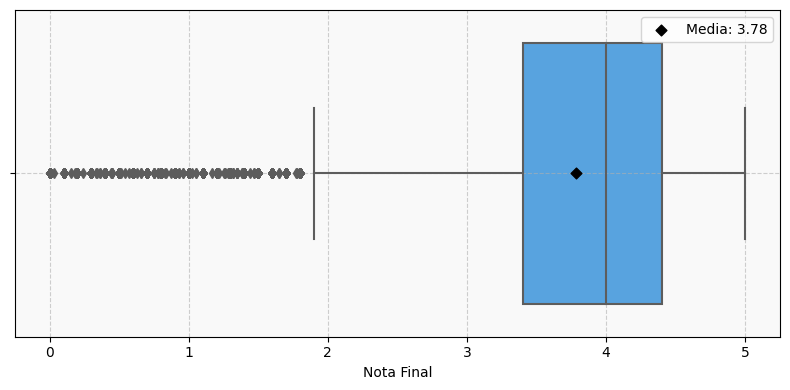

In [67]:
warnings.filterwarnings("ignore", category=FutureWarning)

# Crear figura
fig, ax = plt.subplots(figsize=(8, 4))

# -----------------------
# Boxplot Horizontal
# -----------------------
sns.boxplot(x=df["Nota Final"], color="#42A5F5", fliersize=5, ax=ax)

# Calcular media y añadir marcador
media = df["Nota Final"].mean()
ax.scatter(
    x=media, y=0,
    color="black",
    marker="D",
    s=30,
    zorder=3,
    label=f"Media: {media:.2f}"
)

# Personalización
ax.set_facecolor("#F9F9F9")  # color suave de fondo
ax.grid(True, linestyle="--", alpha=0.6)  # activar cuadrícula en ambos ejes

ax.legend()

plt.tight_layout()
plt.show()

Medidas de tendencia central.

La mediana se ubica en el valor 4, representada por la línea dentro de la caja, La media está representada con un rombo negro y tiene un valor de 3.78.

Medidas de dispersión.

El rango intercuartílico (IQR) se extiende aproximadamente de 3.4 a 4.4, conteniendo el 50% central de los datos. El bigote superior alcanza el valor máximo registrado de 5. El bigote inferior llega hasta un valor cercano a 1.8.

Valores atípicos.

Se observan numerosos valores atípicos en el rango de 0 a 1.8, representados por puntos individuales. Estos valores se encuentran por debajo del límite inferior del bigote, indicando calificaciones más bajas en comparación con la mayoría de los registros.

3.3. Información Académica y Desempeño Estudiantil.

La siguiente tabla muestra un resumen descriptivo de las variables categóricas contenidas en la base de datos: Student Academic Record. Cada fila corresponde a una variable, indicando la cantidad de registros (observaciones), la cantidad de categorías únicas, la categoría más frecuente y su representación en frecuencias absolutas, relativas y porcentuales.

In [68]:
# Variables que se excluyen
excluir = ["Código Estudiantil", "Código Asignatura"]

# Se crea un nuevo DataFrame sin esas variables
df1 = df.drop(columns=excluir, errors="ignore")

# Resumen para variables categóricas
resumen_categorico = df1.describe(include=["object", "category"]).T.reset_index()
resumen_categorico.rename(columns={"index": "Variable", "freq": "A.freq"}, inplace=True)

# Convertir columnas a tipo numérico (por seguridad)
resumen_categorico["A.freq"] = pd.to_numeric(resumen_categorico["A.freq"], errors="coerce")
resumen_categorico["count"] = pd.to_numeric(resumen_categorico["count"], errors="coerce")

# Calcular frecuencia relativa del valor más frecuente
resumen_categorico["R.freq"] = (
    resumen_categorico["A.freq"] / resumen_categorico["count"]
).round(3)

# Crear columna con el porcentaje en formato string con dos decimales y símbolo %
resumen_categorico["Pct"] = resumen_categorico["R.freq"].map(
    lambda x: f"{x*100:.2f}%" if pd.notnull(x) else "N/A"
)

# Definir alineación de columnas (última columna a la derecha)
colalign = ["left"] * (len(resumen_categorico.columns) - 1) + ["center"]

# Mostrar resultados en tabla
print(
    tabulate(
        resumen_categorico,
        headers="keys",
        tablefmt="fancy_grid",
        colalign=colalign,
        showindex=False
    )
)


╒═════════════╤═════════╤══════════╤═════════════════════╤══════════╤══════════╤════════╕
│ Variable    │ count   │ unique   │ top                 │ A.freq   │ R.freq   │  Pct   │
╞═════════════╪═════════╪══════════╪═════════════════════╪══════════╪══════════╪════════╡
│ Facultad    │ 590412  │ 10       │ Ciencias Económicas │ 162135   │ 0.275    │ 27.50% │
├─────────────┼─────────┼──────────┼─────────────────────┼──────────┼──────────┼────────┤
│ Programa    │ 590412  │ 23       │ Derecho             │ 66000    │ 0.112    │ 11.20% │
├─────────────┼─────────┼──────────┼─────────────────────┼──────────┼──────────┼────────┤
│ Asignatura  │ 590412  │ 3999     │ INGLES I            │ 6072     │ 0.01     │ 1.00%  │
├─────────────┼─────────┼──────────┼─────────────────────┼──────────┼──────────┼────────┤
│ Grupo       │ 590412  │ 86       │ A1                  │ 400042   │ 0.678    │ 67.80% │
├─────────────┼─────────┼──────────┼─────────────────────┼──────────┼──────────┼────────┤
│ Rendimie

En la variable Facultad, con 590.412 registros y 10 categorías únicas, la más frecuente es Ciencias Económicas, que aparece 162.135 veces. Esto representa una frecuencia relativa de 0.2750 y un 27.50% del total.

En cuanto a Programa (Académico), que contiene 23 categorías, el más común es Derecho, con 66.000 registros. Esto equivale a una frecuencia relativa de 0.1118 y un 11.18% del total de observaciones.

La variable Asignatura cuenta con 3.999 categorías diferentes, siendo INGLÉS I la más frecuente, con 6.072 apariciones. Su representación porcentual es de 1.00%, lo cual evidencia su baja proporción frente al total de registros.

Respecto al Grupo, con 86 categorías, la más repetida es A1, con 400.042 registros. Esta categoría concentra una frecuencia relativa de 0.6776, es decir, un 67.76% del total de casos.

Por último, la variable Rendimiento, con 5 categorías posibles, tiene como valor más frecuente Alto, con 166.349 registros. Esto equivale a una frecuencia relativa de 0.2817 y un 28.18% del total de observaciones.

3.4. Comportamiento del Rendimiento Académico Estudiantil.

La siguiente figura, corresponde a una gráfica de barras que muestra la distribución de los estudiantes según los niveles de rendimiento académico (alcanzado). En el eje de las ordenadas (es decir, en el eje "y") se encuentra el número de estudiantes, mientras que en el eje de las abscisas (esto es, en el eje "x") se ubican las sesis (06) categorías de rendimiento definidas por intervalos de calificación.

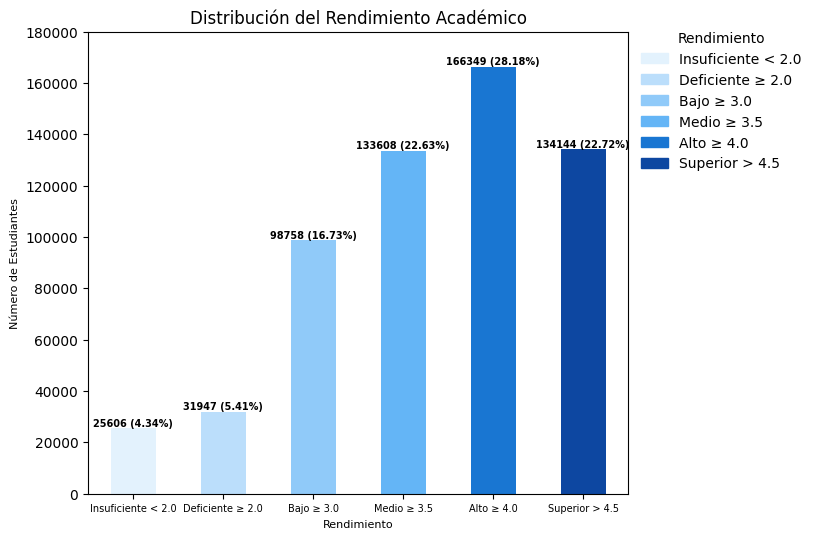

In [69]:
# Conteo de frecuencias de Rendimiento
rendimiento_counts = df['Rendimiento'].value_counts()

# Ordenar categorías jerárquicamente
orden = ["Insuficiente", "Deficiente", "Bajo", "Medio", "Alto", "Superior"]
rendimiento_counts = rendimiento_counts.reindex(orden)

# Calcular porcentajes
total = rendimiento_counts.sum()
rendimiento_perc = (rendimiento_counts / total * 100).round(2)

# Paleta azul degradada (más intenso → más suave)
palette = {
    "Insuficiente": "#E3F2FD",  # Azul muy claro
    "Deficiente": "#BBDEFB",    # Azul suave
    "Bajo": "#90CAF9",          # Azul claro
    "Medio": "#64B5F6",         # Azul medio
    "Alto": "#1976D2",          # Azul fuerte
    "Superior": "#0D47A1"       # Azul muy oscuro
}

# Diccionario de etiquetas con rangos
labels_dict = {
    "Insuficiente": "Insuficiente < 2.0", 
    "Deficiente": "Deficiente ≥ 2.0",
    "Bajo": "Bajo ≥ 3.0",
    "Medio": "Medio ≥ 3.5",
    "Alto": "Alto ≥ 4.0",
    "Superior": "Superior > 4.5"
}

# Gráfico de columnas
ax = rendimiento_counts.plot(
    kind="bar",
    color=[palette[cat] for cat in rendimiento_counts.index],
    figsize=(8, 6)
)

# Fijar escala del eje Y
plt.ylim(0, 180000)

# Etiquetas con valor absoluto y porcentaje (ligeramente más pequeñas)
for i, (count, perc) in enumerate(zip(rendimiento_counts, rendimiento_perc)):
    ax.text(i, count + 0.5, f"{count} ({perc}%)",
            ha='center', va='bottom', fontsize=7, fontweight="bold")

# Ajustar etiquetas del eje X con rangos
ax.set_xticklabels([labels_dict[cat] for cat in rendimiento_counts.index], fontsize=7)

# Agregar leyenda fuera del área del gráfico (corregida)
handles = [plt.Rectangle((0,0),1,1, color=palette[cat]) for cat in orden]
labels = [labels_dict[cat] for cat in orden]
plt.legend(
    handles, labels,
    title="Rendimiento",
    loc="center left",           # centrada verticalmente
    bbox_to_anchor=(1, 0.85),  # fuera del gráfico, a la derecha
    frameon=False
)

# Títulos y etiquetas
plt.title("Distribución del Rendimiento Académico", fontsize=12)
plt.xlabel("Rendimiento", fontsize=8)
plt.ylabel("Número de Estudiantes", fontsize=8)
plt.xticks(rotation=0)

# Ajustar márgenes (añadir espacio a la derecha)
plt.subplots_adjust(right=0.8)

plt.show()

In [70]:
# Conteo de frecuencias de Rendimiento
rendimiento_counts = df['Rendimiento'].value_counts()

# Ordenar categorías jerárquicamente
orden = ["Insuficiente", "Deficiente", "Bajo", "Medio", "Alto", "Superior"]
rendimiento_counts = rendimiento_counts.reindex(orden)

# Calcular porcentajes
total = rendimiento_counts.sum()
rendimiento_perc = (rendimiento_counts / total * 100).round(2)

# Diccionario de etiquetas con rangos
labels_dict = {
    "Insuficiente": "Insuficiente < 2.0", 
    "Deficiente": "Deficiente ≥ 2.0",
    "Bajo": "Bajo ≥ 3.0",
    "Medio": "Medio ≥ 3.5",
    "Alto": "Alto ≥ 4.0",
    "Superior": "Superior > 4.5"
}

# Crear tabla resumen (sin columna Categoría)
tabla_rendimiento = pd.DataFrame({
    "Categoría": [labels_dict[cat] for cat in rendimiento_counts.index],
    "Frecuencia": rendimiento_counts.values,
    "Porcentaje (%)": rendimiento_perc.values
}).fillna({'Frecuencia': 0, 'Porcentaje (%)': 0})

# Mostrar tabla con título incluido
display(
    tabla_rendimiento.style
        .set_caption("Distribución del Rendimiento Académico")
        .set_table_styles([
            {"selector": "caption", "props": [("caption-side", "top"), ("font-size", "12pt"), ("text-align", "center"), ("font-weight", "bold"), ("padding-bottom", "8px")]},
            {"selector": "th", "props": [("font-size", "11pt"), ("text-align", "center")]},
            {"selector": "td", "props": [("font-size", "10pt")]}
        ])
        .set_properties(subset=["Categoría"], **{"text-align": "left"})
        .set_properties(subset=["Frecuencia", "Porcentaje (%)"], **{"text-align": "right"})
        .format({"Frecuencia": "{:,.0f}", "Porcentaje (%)": "{:.2f}"})
)

,Categoría,Frecuencia,Porcentaje (%)
0,Insuficiente < 2.0,"25,606",4.34
1,Deficiente ≥ 2.0,"31,947",5.41
2,Bajo ≥ 3.0,"98,758",16.73
3,Medio ≥ 3.5,"133,608",22.63
4,Alto ≥ 4.0,"166,349",28.18
5,Superior > 4.5,"134,144",22.72


El nivel Insuficiente (< 2.00), se corresponde con 25.606 estudiantes, que equivale al 4.34%. El nivel Deficiente (≥ 2.00) cuenta con 31.947 estudiantes, lo que representa el 5.41% del total. El nivel Bajo (≥ 3.00) agrupa a 98.758 estudiantes, equivalentes al 16.73%. Posteriormente, el nivel Medio (≥ 3.50) alcanza un total de 133.608 estudiantes, que corresponden al 22.63% de la muestra.

La categoría Alto (≥ 4.00) concentra la mayor proporción de estudiantes, con 166.349 casos, es decir, el 28.18% del total. Por su parte, el nivel Superior (> 4.50) reúne 134.144 estudiantes, equivalente al 22.72%.

En conjunto, la gráfica permite visualizar la distribución de las frecuencias absolutas y relativas de los estudiantes en cada nivel de rendimiento, destacando la presencia de un mayor número de estudiantes en las categorías altas en comparación con las más bajas.

3.5. Nota Final Promedio por Programa Académico.

La siguiente figura corresponde a una gráfica de barras horizontales que muestra el valor medio de la nota final por cada programa académico. En el eje de las ordenadas (es decir, en el eje de las "y") se encuentran listados los programas, mientras que en el eje de las abscisas (esto es, en el eje de las "x") se representan las notas promedio, con un rango que va de 0 a 5.

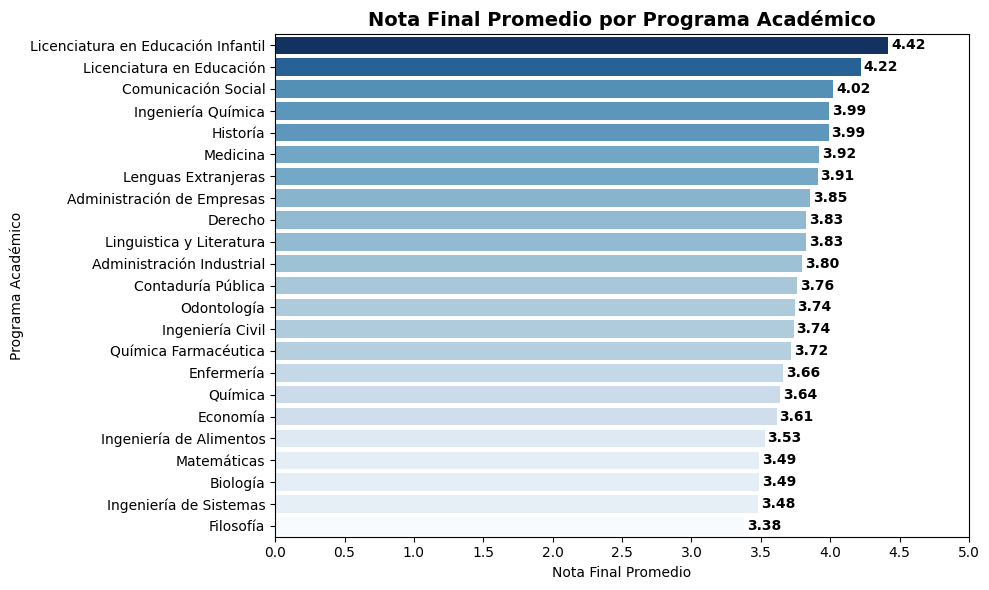

In [71]:
warnings.filterwarnings("ignore", category=FutureWarning)

# Calcular promedios de Nota Final por Programa
program_means = df.groupby("Programa")["Nota Final"].mean().sort_values(ascending=False)

# Normalizar valores para asignar colores (0 → más bajo, 1 → más alto)
norm = plt.Normalize(program_means.min(), program_means.max())
cmap = plt.cm.Blues

# Gráfico de barras con degradación azul
plt.figure(figsize=(10,6))
ax = sns.barplot(
    x=program_means.values,
    y=program_means.index,
    hue=program_means.index,  
    palette=[cmap(norm(val)) for val in program_means.values],
    dodge = False,
)

# Ocultar la leyenda (opcional)
if ax.legend_:
    ax.legend_.remove()

# Añadir etiquetas con el valor numérico al final de cada barra
for i, val in enumerate(program_means.values):
    ax.text(
        val + 0.02,        # un poco a la derecha de la barra
        i,                 # posición en el eje Y
        f"{val:.2f}",      # redondear a 2 decimales
        va='center',
        ha='left',
        fontsize=10,
        fontweight="bold"
    )

# Personalización
plt.title("Nota Final Promedio por Programa Académico", fontsize=14, weight="bold")
plt.xlabel("Nota Final Promedio")
plt.ylabel("Programa Académico")
plt.gca().xaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f'))

# Ajuste del intervalo del eje X
ax.set_xlim(0, 5)
ax.set_xticks(np.arange(0, 5.5, 0.5))

plt.tight_layout()
plt.show()

El programa con el promedio más alto es Licenciatura en Educación Infantil, con un valor de 4.42, seguido por Licenciatura en Educación, con 4.22. Posteriormente aparecen Comunicación Social con 4.02, e Ingeniería Química e Historia, ambos con 3.99. Estos programas conforman el grupo con las calificaciones promedio más elevadas dentro de la gráfica.

En un nivel intermedio se encuentran programas como Medicina (3.92), Lenguas Extranjeras (3.91), Administración de Empresas (3.85), Derecho (3.83), Lingüística y Literatura (3.83) y Administración Industrial (3.80). Todos ellos se ubican cerca del valor de 3.8, representando una franja de desempeño medio-alto.

Más abajo se sitúan programas como Contaduría Pública (3.76), Odontología (3.74), Ingeniería Civil (3.74) y Química Farmacéutica (3.72), seguidos por Enfermería (3.66), Química (3.64) y Economía (3.61).

Finalmente, los promedios más bajos corresponden a programas como Ingeniería de Alimentos (3.53), Matemáticas (3.49), Biología (3.49), Ingeniería de Sistemas (3.48) y Filosofía (3.38), este último siendo el menor valor registrado en la gráfica.

En conjunto, la visualización permite comparar los distintos programas académicos según el promedio de la nota final, mostrando una variación que va desde 4.42 hasta 3.38.

In [72]:
# 0) Definir el orden de Rendimiento
orden_rend = ["Insuficiente", "Deficiente", "Bajo", "Medio", "Alto", "Superior"]
df["Rendimiento"] = pd.Categorical(df["Rendimiento"], categories=orden_rend, ordered=True)

# 1) Calcular promedios por rendimiento (pivot)
promedios = df.pivot_table(
    values="Nota Final",
    index="Programa",
    columns="Rendimiento",
    aggfunc="mean",
    observed=False
).round(2)

# 2) Calcular conteos y porcentajes por rendimiento
conteos = df.pivot_table(
    values="Nota Final",
    index="Programa",
    columns="Rendimiento",
    aggfunc="count",
    observed=False
)
totales = conteos.sum(axis=1)
porcentajes = (conteos.div(totales, axis=0) * 100).round(1)

# 3) Combinar promedios y porcentajes en texto por celda
tabla_final = promedios.combine(
    porcentajes,
    lambda prom, perc: prom.round(2).astype(str) + " (" + perc.round(1).astype(str) + "%)"
)

# 4) Resetear índice para tener 'Programa' como columna
tabla_final = tabla_final.reset_index()

# ---------- PROMEDIO GENERAL ----------
# 4a) Calcular Promedio General numérico por Programa
promedios_generales = df.groupby("Programa")["Nota Final"].mean().round(2)

# 4b) Calcular porcentaje relativo al mejor programa (máximo promedio)
max_programa = promedios_generales.max()
porcentajes_generales = ((promedios_generales / max_programa) * 100).round(1)

# 4c) Crear una Series formateada indexada por 'Programa'
formatted_general = promedios_generales.astype(str) + " (" + porcentajes_generales.astype(str) + "%)"

# 4d) Asignar la columna usando map (alineación por nombre de Programa)
tabla_final["Promedio General"] = tabla_final["Programa"].map(lambda x: f"{promedios_generales[x]:.2f}")

# 4e) Reordenar la tabla según el Promedio General numérico (de mayor a menor)
orden_promedio = promedios_generales.sort_values(ascending=False).index
tabla_final = tabla_final.set_index("Programa").loc[orden_promedio].reset_index()

# 5) Crear MultiIndex para las columnas (incluyendo Promedio General)
tabla_final.columns = pd.MultiIndex.from_tuples(
    [("","Programa")] +
    [("Rendimiento Académico", col) for col in orden_rend] +
    [("","Media")]
)

# 6) Estilizar tabla
styled = (
    tabla_final.style
    .set_caption("Distribución de la Nota Final Promedio por Rendimiento y Programa Académico")
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size", "16px"), ("font-weight", "bold"), ("color", "white")]},
        {"selector": "th",
         "props": [("text-align", "center")]},
        {"selector": "td",
         "props": [("text-align", "right")]},
        {"selector": "td:first-child",
         "props": [("text-align", "left")]}
    ])
    .hide(axis="index")
)
styled

3.6. Nota Final Promedio por Año y Período Académico.

La siguiente gráfica de columnas muestra la evolución del valor medio de la nota final entre los años 2014 y 2023, diferenciado por períodos académicos (a saber: 1 semestre y 2 semestre). En general, los valores se mantienen relativamente estables en la mayoría de los años, con un comportamiento particular en el 2020 y 2021.

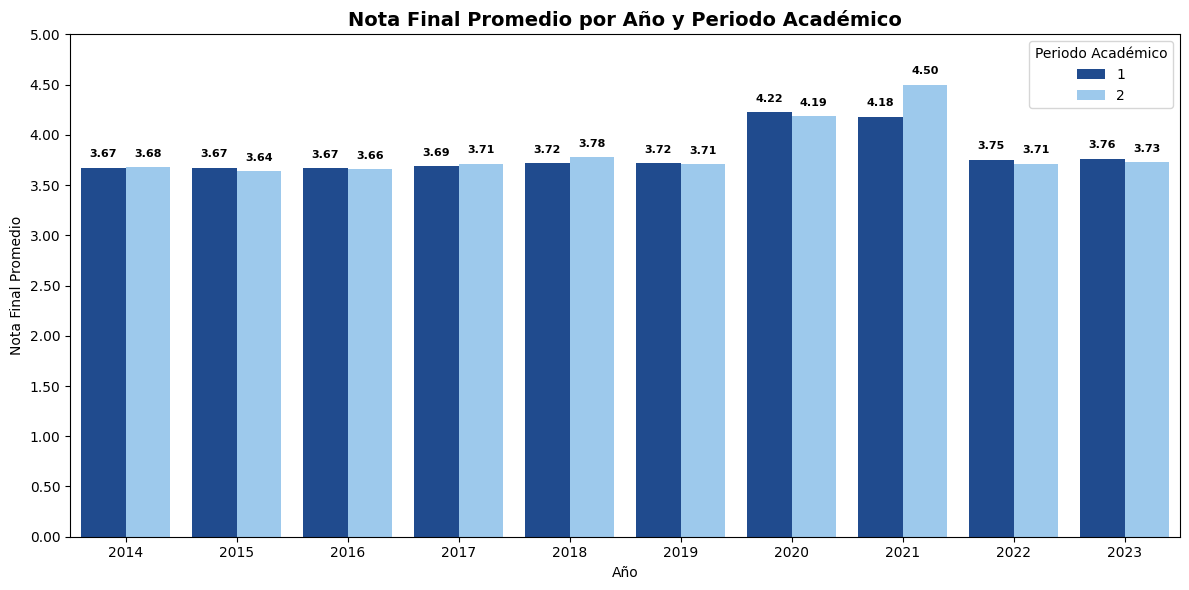

In [73]:
# 1) Calcular promedios por Año y Periodo
df_prom = (
    df.groupby(["Año", "Periodo"], as_index=False)["Nota Final"]
      .mean()
      .sort_values(["Año", "Periodo"])
)

# 2) Crear gráfico de columnas agrupadas por Periodo dentro de cada Año
plt.figure(figsize=(12,6))
ax = sns.barplot(
    data=df_prom,
    x="Año",
    y="Nota Final",
    hue="Periodo",
    palette=["#0D47A1","#90CAF9"],
    errorbar=None
)

# 3) Personalización
ax.set_title("Nota Final Promedio por Año y Periodo Académico", fontsize=14, weight="bold")
ax.set_xlabel("Año")
ax.set_ylabel("Nota Final Promedio")

# Eje Y: formato con dos decimales y escalas de 0.5 en 0.5
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f'))
ax.yaxis.set_major_locator(MultipleLocator(0.5))

# Ajustar límites del eje Y hasta el múltiplo superior más cercano
ymax = df_prom["Nota Final"].max()
ax.set_ylim(0, round(ymax + 0.5, 1))

# 4) Agregar etiquetas de datos (dos decimales) en cada barra
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{height:.2f}',
        xy=(p.get_x() + p.get_width() / 2, height),
        xytext=(0, 6),
        textcoords="offset points",
        ha="center", va="bottom",
        fontsize=8, fontweight="bold", color="black"
    )

# 5) Ajustes finales
plt.legend(title="Periodo Académico")
plt.tight_layout()
plt.show()

Entre 2014 y 2019, los promedios rondan entre 3.64 y 3.78, evidenciando estabilidad y sin variaciones significativas entre los dos períodos de cada año. Los valores más bajos de este lapso se observan en 2015 (3.64 en el período 2) y los más altos en 2018 (3.78 en el período 2).

En el año 2020 se presenta un incremento destacado, con promedios de 4.22 en el período 1 y 4.19 en el período 2, lo que representa un aumento considerable respecto a los años anteriores. Esta tendencia ascendente se acentúa en 2021, donde se alcanzan los valores más altos de toda la serie: 4.18 en el período 1 y un máximo de 4.50 en el período 2.

A partir de 2022, los promedios retornan a niveles similares a los de años previos, ubicándose entre 3.75 y 3.71 en 2022 y en 3.76 y 3.73 en el 2023, lo que sugiere un regreso a la estabilidad después del repunte observado entre 2020 y el 2021.

En conclusión, la gráfica refleja un comportamiento estable en los promedios entre 2014 y 2019, un repunte significativo en 2020 y 2021 y un retorno a valores regulares en los años posteriores.

In [74]:
# Definir orden de rendimiento
orden_rend = ["Insuficiente", "Deficiente", "Bajo", "Medio", "Alto", "Superior"]

# Crear tabla tipo matriz: promedio de Nota Final
tabla_pivot = (
    df.pivot_table(
        values="Nota Final",
        index=["Año", "Periodo"],
        columns="Rendimiento",
        aggfunc="mean",
        observed=False
    )
    .reindex(columns=orden_rend)   # forzar el orden
    .round(2)                      # dos decimales
    .reset_index()                 # Año y Periodo como columnas normales
)

# Calcular porcentajes fila por fila (distribución por Año y Periodo)
valores = tabla_pivot[orden_rend]
porcentajes = valores.div(valores.sum(axis=1), axis=0) * 100

# Combinar promedio y porcentaje en formato "X.XX (YY%)"
tabla_fmt = tabla_pivot.copy()
for col in orden_rend:
    tabla_fmt[col] = (
        valores[col].fillna(0).map("{:.2f}".format)
        + " (" +
        porcentajes[col].fillna(0).map("{:.1f}%".format)
        + ")"
    )

# ---------- NUEVO BLOQUE: calcular media general por Año y Periodo ----------
media_general = (
    df.groupby(["Año", "Periodo"])["Nota Final"].mean().round(2).reset_index(drop=True)
)

# Añadir columna de media al DataFrame formateado
tabla_fmt["Media"] = media_general.map("{:.2f}".format)

# Crear MultiIndex para encabezado de Rendimiento Académico
tabla_fmt.columns = pd.MultiIndex.from_tuples(
    [("", "Año"), ("", "Periodo")] +
    [("Rendimiento Académico", col) for col in orden_rend] +
    [("", "Media")]
)

# Estilo sobrio en blanco y negro
styled = (
    tabla_fmt.style
    .set_caption("Distribución de la Nota Final Promedio por Rendimiento Académico, Año y Periodo")
    .set_table_styles([
        {"selector": "caption", "props": [("text-align", "center"),
                                          ("font-weight", "bold"),
                                          ("font-size", "14px")]},
        {"selector": "th", "props": [("text-align", "center"),
                                     ("font-weight", "bold"),
                                     ("border", "1px solid black")]},
        {"selector": "td", "props": [("text-align", "center"),
                                     ("border", "1px solid black")]},
        {"selector": "td:first-child",
         "props": [("text-align", "center")]}
    ])
    .hide(axis="index")
)

display(styled)

3.7. Prueba Paramétrica: Correlación de Pearson.

La siguiente tabla, muestra la relación entre las notas parciales y la Nota Final mediante el coeficiente de correlación de Pearson. Los resultados dan cuenta de un comportamientos heterogéneos en cuanto a la magnitud y dirección de las asociaciones.

In [75]:
# Variables independientes
variables = ["Nota 1", "Nota 2", "Nota 3", "Nota 4",
             "Nota Definitiva", "Nota Habilitación"]

# Calcular correlaciones de Pearson con "Nota Final"
pearson_corr = (
    df[variables + ["Nota Final"]]
    .corr(method="pearson")["Nota Final"]
    .drop("Nota Final")
    .round(3)
)

# Crear DataFrame de resultados
corr_results = pd.DataFrame({
    "Correlación Pearson": pearson_corr
})

# Dar estilo en blanco y negro (bordes, centrado, sin colores)
corr_results = corr_results.style.set_table_styles(
    [
        {"selector": "thead th", "props": [
            ("font-size", "14px"),
            ("text-align", "center"),
            ("font-weight", "bold"),
            ("border", "1px solid black")
        ]},
        {"selector": "tbody td", "props": [
            ("font-size", "13px"),
            ("text-align", "center"),
            ("border", "1px solid black")
        ]},
        {"selector": "tbody th", "props": [
            ("font-size", "13px"),
            ("text-align", "left"),
            ("font-weight", "bold"),
            ("border", "1px solid black")
        ]}
    ]
).set_caption("Correlación de las Notas (-por corte-) con la 'Nota Final' (r-Pearson)")

# Mostrar tabla en Jupyter Notebook
display(corr_results)

,Correlación Pearson
Nota 1,0.146000
Nota 2,0.176000
Nota 3,0.563000
Nota 4,0.019000
Nota Definitiva,0.989000
Nota Habilitación,-0.078000


La Nota 1 presenta un coeficiente de correlación de Pearson de 0.1460, mientras que la Nota 2 registra un valor de 0.1760. Ambos resultados indican asociaciones positivas de baja magnitud con la Nota Final.

La Nota 3 alcanza un coeficiente de Pearson de 0.5630, valor que representa la asociación positiva más alta entre las notas parciales y la Nota Final.

Por otro lado, la Nota 4 muestra un valor de 0.019, prácticamente nulo, lo que evidencia ausencia de relación monótona con la Nota Final.

La Nota Definitiva registra un coeficiente de Pearson de 0.9890, siendo el valor más alto en la tabla y reflejando una asociación positiva casi perfecta con la Nota Final.

Finalmente, la Nota de Habilitación presenta un coeficiente negativo de -0.078, indicando una asociación inversa de baja magnitud con la Nota Final.

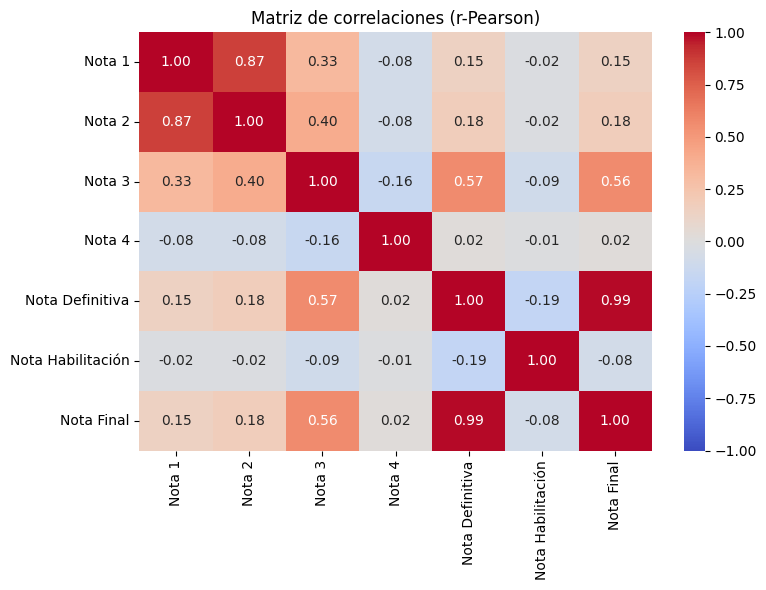

In [76]:
# Seleccionamos solo las variables de interés
vars_notas = ["Nota 1", "Nota 2", "Nota 3", "Nota 4",
              "Nota Definitiva", "Nota Habilitación", "Nota Final"]

# Crear figura
plt.figure(figsize=(8, 6))

# Heatmap Pearson
sns.heatmap(df[vars_notas].corr(method="pearson"),
            annot=True, cmap="coolwarm", center=0, fmt=".2f", vmin=-1, vmax=1)

plt.title("Matriz de correlaciones (r-Pearson)")
plt.tight_layout()
plt.show()

3.8. Prueba de Independencia: Prueba Chi-cuadrado.

El análisis estadístico realizado mediante la prueba Chi-cuadrado de independencia permite establecer si existe una relación significativa entre el Rendimiento (académico) de los estudiantes y las variables Programa (académico) y Asignatura. Los resultados muestran que, en todos los casos evaluados, el valor p fue prácticamente cero, lo que indica una fuerte evidencia para rechazar la hipótesis nula de independencia. En otras palabras, se confirma que sí existe asociación entre las variables analizadas y el Rendimiento (académico).

In [77]:
# Función para correr Chi² entre dos variables categóricas
def prueba_chi2(var_filas, var_columnas, nombre):
    tabla = pd.crosstab(df[var_filas], df[var_columnas])
    chi2, p, dof, ex = chi2_contingency(tabla)
    interpretacion = "Sí existe asociación" if p < 0.05 else "No existe asociación"
    return {
        "Comparación": f"{nombre} ~ {var_columnas}",
        "Estadístico Chi²": chi2,
        "Grados de libertad": dof,
        "Valor p": p,
        "Interpretación": interpretacion
    }

# Ejecutar pruebas
res1 = prueba_chi2("Programa", "Rendimiento", "Programa")
res2 = prueba_chi2("Asignatura", "Rendimiento", "Asignatura")

# Unir resultados en DataFrame
resultados = pd.DataFrame([res1, res2])

# Mostrar en Notebook
display(
    resultados.style
    .format({
        "Estadístico Chi²": "{:,.2f}",
        "Valor p": "{:.4e}"
    })
    .set_caption("Pruebas Chi-Cuadrado de Independencia")
    # Alinear las celdas de la columna Comparación
    .set_properties(subset=["Comparación"], **{"text-align": "left"})
    # Alinear también el encabezado de la columna Comparación
    .set_table_styles([
        {"selector": "th.col_heading.level0", "props": [("text-align", "left")]}
    ], overwrite=False)
)

,Comparación,Estadístico Chi²,Grados de libertad,Valor p,Interpretación
0,Programa ~ Rendimiento,"56,426.04",110,0.0000e+00,Sí existe asociación
1,Asignatura ~ Rendimiento,"409,547.14",19990,0.0000e+00,Sí existe asociación


En primer lugar, se encontró que el Rendimiento (académico) depende del Programa (académico) en el que se encuentra matriculado el estudiante. Esto significa que la distribución de los niveles de Rendimiento (es decir, Insuficiente, Deficiente, Bajo, Medio, Alto y Superior) no es homogénea entre los diferentes programas, sino que algunos de ellos tienden a concentrar mayor o menor proporción de estudiantes con Rendimientos destacados y, en segundo lugar, al analizar la relación entre las Asignaturas y el Rendimiento (académico), se observó una asociación aún más fuerte. Esto refleja que el tipo de Asignatura influye significativamente en el desempeño de los estudiantes.

Conclusiones

Este documento presenta un Análisis Exploratorio de los Datos (-EDA-) sobre el Rendimiento (académico) de estudiantes de una Institución de Educación Superior en Colombia y sus principales factores asociados, a partir del conjunto de datos denominado “Student Academic Record (SAR)”, compuesto por 590.412 observaciones y 16 variables (sin valores faltantes). Las variables se agrupan en cuatro categorías principales: Información Académica, Récord de Notas, Desempeño estudiantil y temporalidad, siendo la variable de interés el Rendimiento Académico (categórica ordinal).

Los resultados preliminares evidencian que las Notas 1 y 2 presentan bajos promedios y alta dispersión; la Nota 3 concentra calificaciones altas y muestra la mayor correlación con la Nota Final (𝜌 = 0.5630); la Nota 4 se caracteriza por ausencia de registros significativos; mientras que la Nota Definitiva y la Nota Final reflejan una fuerte concentración en calificaciones altas y una asociación casi perfecta (𝜌 = 0.9890). La Nota de Habilitación, en contraste, es poco frecuente y se relaciona negativamente con la Nota Final.

Finalmente, los análisis de asociación mediante Chi-cuadrado revelaron dependencias significativas entre el Rendimiento (académico) y variables como el Programa y, en mayor medida, las Asignaturas, lo que sugiere, en principio, que el tipo de materia/curso es el factor más influyente en el desempeño estudiantil.

Referencias

Alyahyan, E., & Düştegör, D. (2020). Predicting academic success in higher education: literature review and best practices. International journal of educational technology in higher education, 17(1), 3.

Gallego, M. G., Perez de los Cobos, A. P., & Gallego, J. C. G. (2021). Identifying students at risk to academic dropout in higher education. Education Sciences, 11(8), 427.

Laboratorio de Economía de la Educación (LEE) de la Pontificia Universidad Javeriana. (2023). Informe No. 74 Deserción en la educación superior en Colombia. Disponible en

Pérez, B., Castellanos, C., & Correal, D. (2018, May). Predicting student drop-out rates using data mining techniques: A case study. In IEEE Colombian Conference on Applications in Computational Intelligence (pp. 111-125). Cham: Springer International Publishing.

Realinho, V., Machado, J., Baptista, L., & Martins, M. V. (2022). Predicting student dropout and academic success. Data, 7(11), 146.

Valencia-Arias, A., Chalela, S., Cadavid-Orrego, M., Gallegos, A., Benjumea-Arias, M., & Rodríguez-Salazar, D. Y. (2023). University dropout model for developing countries: A Colombian context approach. Behavioral Sciences, 13(5), 382.

Imig, P. G. (2020). Rendimiento académico: un recorrido conceptual que aproxima a una definición unificada para el ámbito superior/Academic performance: a conceptual journey that approximates a unified definition for the higher level. Revista de Educación, (20), 89-104.

Rico Páez, A., & Sánchez Guzmán, D. (2018). Diseño de un modelo para automatizar la predicción del rendimiento académico en estudiantes del IPN. RIDE. Revista Iberoamericana para la Investigación y el Desarrollo Educativo, 8(16), 246-266.